# Superstore Sales Profit Prediction

This project focuses on predicting **Profit** using the Superstore dataset.

### Objectives:
- Perform data cleaning and preprocessing
- Explore relationships between variables
- Build a Machine Learning model to predict profit
- Evaluate model performance

### Tools Used:
- Python
- Pandas, NumPy
- Matplotlib, Seaborn
- Scikit-learn

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [24]:
data = pd.read_csv("C:/Users/ashay/Documents/Data Science/archive/Sample - Superstore.csv", encoding='latin1')

In [25]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [26]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [27]:
print(data.isna().sum())
print(data.duplicated().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
0


In [28]:
# Changing the Order Date and Ship Date columns data types from object data type to date time data type.

data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

In [29]:
# Dropping the columns that are no use to our ML Project.

data = data.drop(['Row ID', 'Order ID', 'Customer ID', 'Customer Name', 'Product ID', 'Product Name'], axis=1)
data.head()

,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,2016-11-08,2016-11-11,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,2016-11-08,2016-11-11,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,2016-06-12,2016-06-16,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,2015-10-11,2015-10-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,2015-10-11,2015-10-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


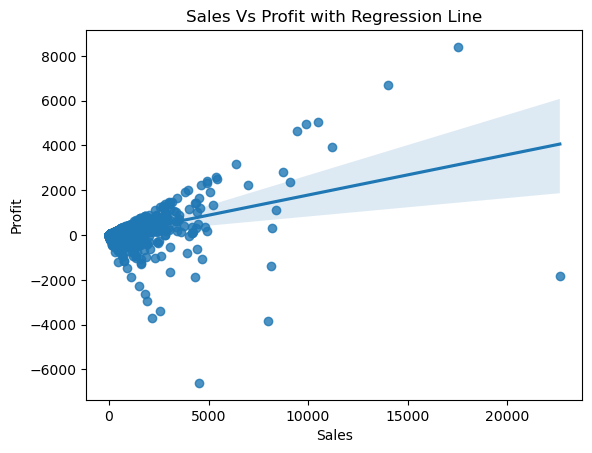

In [30]:
# Visualized relationship between Sales and Profit using scatter plot and regression line

sns.regplot(x='Sales', y='Profit', data=data)

plt.title('Sales Vs Profit with Regression Line')
plt.show()

--Insights
- Most sales occur in lower range (0-5000)
- Profit shows weak positive correlation with sales
- Presence of outliers (high loss and high profit)

In [31]:
# Creating new columns Order Year and Order Month by extracting Order Date column
data['Order Year'] = data['Order Date'].dt.year
data['Order Month'] = data['Order Date'].dt.month

# Dropping Order Date, Ship Date, City, State, Postal Code columns from the Data to prevent a large number of columns which can reduce computing speed
data = data.drop(['Order Date', 'Ship Date', 'City', 'State', 'Postal Code'], axis=1)

In [32]:
# Encoding the data as there are text columns in the Data
#drop_first=True parameter reduces the computing load

data = pd.get_dummies(data, drop_first=True) 
data.head()

,Sales,Quantity,Discount,Profit,Order Year,Order Month,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,261.9600,2,0.00,41.9136,2016,11,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,731.9400,3,0.00,219.5820,2016,11,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,14.6200,2,0.00,6.8714,2016,6,False,True,False,True,...,False,False,False,True,False,False,False,False,False,False
3,957.5775,5,0.45,-383.0310,2015,10,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
4,22.3680,2,0.20,2.5164,2015,10,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [33]:
# Splitting the Data

#first we need to import split function from Scikit-learn library
from sklearn.model_selection import train_test_split

# Assigning data to x and y variables
x = data.drop('Profit', axis=1)
y = data['Profit']

# Splitting the data for training and testing among x and y variables. Assigning 20% to the test size (0.2) and the remaining for training size
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [34]:
# Training the model

# first importing the Linear Regression model from the Scikit library
from sklearn.linear_model import LinearRegression

model = LinearRegression() # Creates the brain
model.fit(x_train, y_train) # Trains the data

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
# Prediction
y_pred = model.predict(x_test)

# Evaluation

# first importing r2_score
from sklearn.metrics import r2_score

# Checking the r2_score
r2 = r2_score(y_test, y_pred)
n = x_test.shape[0]
p = x_test.shape[1]

# Using Adjusted r square since we have many features
adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

print("R2:", r2)
print("Adjusted R2:", adj_r2)

R2: -0.6453686008372239
Adjusted R2: -0.6712996769053245


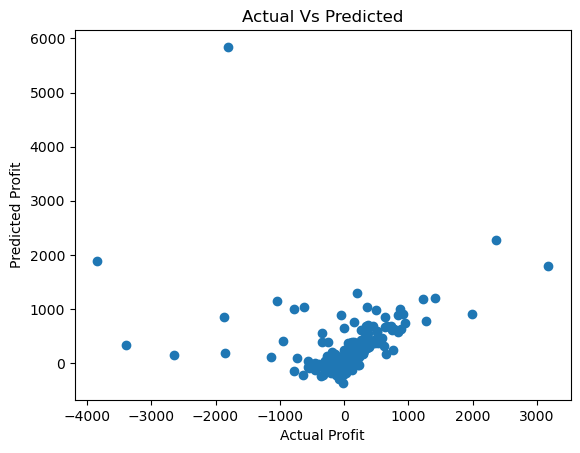

In [37]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual Vs Predicted")
plt.show()

### Key Insights:
- Most sales occur in the lower range (0-5000)
- Profit shows a weak positive relationship with sales
- Presence of outliers (both high profit and high loss)
- Data is highly scattered, indicating weak linear relationship

## Conclusion
- Linear Regression was applied to predict profit
- Model performance was poor (negative R square score)
- This indicates that profit cannot be accurately predicted using a simple linear model

### Future Improvements:
- Try advanced models like Decision Tree or Random Forest
- Perform better feature engineering
- Handle outliers more effectively

---
This Project demonstrates the complete Machine Learning workflow from data preprocessing to model evaluation.